# 04-2. 확률적 경사 하강법

## 0. 개념 정리

```
[훈련 세트] ──▶ 샘플 꺼내기 ──▶ [경사 따라 이동] ──▶ 모두 사용? ──▶ 1 에포크 완료
                  │                                    │
                  │                                    │ 아니오
                  │                                    ▼
                  │                              [계속 반복]
                  │
                  ├── 1개씩 ─────────▶ 확률적 경사 하강법
                  ├── 여러 개씩 ─────▶ 미니배치 경사 하강법
                  └── 전체 ──────────▶ 배치 경사 하강법

※ 1 에포크 완료 후 → 훈련 세트 다시 채우고 반복 (수십~수백 에포크 수행)
```

---

## 1. 점진적 학습(Online Learning)
- 이전에 훈련한 모델을 버리지 않고 새로운 데이터에 대해서만 조금씩 더 훈련하는 방식
- 대표적인 점진적 학습 알고리즘은 확률적 경사 하강법(Stochastic Gradient Descent)

### 1.1. 등장 배경
- 훈련 데이터가 한 번에 준비되는 것이 아니라 조금씩 전달되는 상황이라고 가정했을 때, 기존 훈련 데이터에 새로운 데이터를 추가하여 모델을 매일매일 다시 훈련하면 시간이 지날수록 데이터가 늘어나 서버를 늘려야 함
- 이전 데이터 중 일부를 버리는 방식은 중요한 데이터가 포함되어 있다면 모델이 그 데이터를 제대로 예측하지 못하게 됨

    ##### ⇒ 이때 등장한 게 점진적 학습!

---

## 2. 경사 하강법(Gradient Descent)

### 2.1. 경사 하강법(Gradient Descent)
- 가장 가파른 경사를 따라 원하는 지점에 도달하는 것이 목표
- 가장 가파른 길을 찾아 내려오지만 조금씩 내려오는 것이 중요함
- 이렇게 내려오는 과정이 바로 경사 하강법 모델을 훈련하는 것

### 2.2. 확률적 경사 하강법(Stochastic Gradient Descent)
- 확률적이란 말은 '무작위하게' 혹은 '랜덤하게'의 기술적인 표현
- 훈련 세트에서 랜덤하게 하나의 샘플을 선택하여 가파른 경사를 조금 내려감
- 그다음 훈련 세트에서 랜덤하게 또 다른 샘플을 하나 선택하여 경사를 조금 내려감
- 이런 식으로 전체 샘플을 모두 사용할 때까지 계속함
- e.g.
    - 경사 하강법으로 내려올 때 가장 가파른 길을 찾는 방법은 훈련 세트를 사용해 모델을 훈련하기 때문에 훈련 세트를 사용하여 가장 가파른 길을 찾음
    - 전체 샘플을 사용하지 않고 딱 하나의 샘플을 훈련 세트에서 랜덤하게 골라 가장 가파른 길을 찾음

### 2.3. 에포크(Epoch)
- 확률적 경사 하강법에서 훈련 세트를 한 번 모두 사용하는 과정
- 일반적으로 경사 하강법은 수십, 수백 번 이상 에포크를 수행함

### 2.4. 미니배치 경사 하강법(Minibatch Gradient Descent) 
- 무작위로 몇 개의 샘플을 선택해서 경사를 따라 내려가는 방식
- 여러 개의 샘플을 사용해 경사 하강법을 수행함

### 2.5. 배치 경사 하강법(Batch Gradient Descent)
- 한 번 경사로를 따라 이동하기 위해 전체 샘플을 사용함
- 전체 데이터를 사용하기 때문에 가장 안정적인 방법이 될 수 있음
- 하지만 전체 데이터를 사용하면 그만큼 컴퓨터 자원을 많이 사용하게 됨
- 또, 어떤 경우는 데이터가 너무 많아 한 번에 전체 데이터를 모두 읽을 수 없을지도 모름

---

## 3. 손실 함수(Loss Function)

### 3.1. 손실 함수(Loss Function)
- 머신 러닝 알고리즘이 얼마나 엉터리인지를 측정하는 기준
- 손실 함수의 값이 작을수록 좋음
- 하지만 어떤 값이 최솟값인지는 알지 못함
    
    → 가능한 많이 찾아보고 만족할만한 수준이라면 산을 다 내려왔다고 인정해야 함
- 이 값을 찾아서 조금씩 이동하려면 확률적 경사 하강법이 잘 맞음

### 3.2. 비용 함수(cost function)
- 비용 함수(cost function)는 손실 함수의 다른 말
- 엄밀히 말하면 손실 함수는 샘플 하나에 대한 손실을 정의하고 비용 함수는 훈련 세트에 있는 모든 샘플에 대한 손실 함수의 합을 말함
- 하지만 보통 이 둘을 엄격히 구분하지 않고 섞어서 사용함

### 3.3. 손실 함수가 연속적이어야 하는 이유
- 경사 하강법을 사용할 때 아주 조금씩 내려와야 함
- 정확도처럼 듬성듬성한 값(0, 0.25, 0.5, 0.75, 1)은 경사 하강법을 이용해 조금씩 움직일 수 없음
- 산의 경사면은 확실히 연속적이어야 함
- 기술적으로 말하면 손실 함수는 미분 가능해야 함

### 3.4. 로지스틱 손실 함수 (이진 크로스엔트로피 손실 함수)

- 이진 분류에서 사용하는 손실 함수
- 로지스틱 회귀 모델이 만들어지는 손실 함수
- 예측 확률을 사용해 연속적인 손실 함수를 만들 수 있음

#### (1) 계산 방식

| 타깃 | 예측 확률 | 손실 계산 |
|-----|---------|---------|
| 1 (양성) | 0.9 | -log(0.9) → 작은 손실 |
| 1 (양성) | 0.3 | -log(0.3) → 큰 손실 |
| 0 (음성) | 0.2 | -log(1-0.2) = -log(0.8) → 작은 손실 |
| 0 (음성) | 0.8 | -log(1-0.8) = -log(0.2) → 큰 손실 |

#### (2) 공식

- 양성 클래스(타깃 = 1)일 때: $-\log(예측 확률)$
- 음성 클래스(타깃 = 0)일 때: $-\log(1 - 예측 확률)$

#### (3) 특징

- 예측이 1에 가까울수록 예측과 타깃의 곱의 음수는 점점 작아짐
- 로그 함수는 0~1 사이에서 음수가 되므로 최종 손실 값은 양수가 됨
- 로그 함수는 0에 가까울수록 아주 큰 음수가 되기 때문에 손실을 아주 크게 만들어 모델에 큰 영향을 미칠 수 있음

### 3.5. 크로스엔트로피 손실 함수
- 다중 분류에서 사용하는 손실 함수
- 이진 분류의 로지스틱 손실 함수와 매우 비슷함

### 3.6. 회귀에서 사용하는 손실 함수
- **평균 절댓값 오차(MAE)**: 타깃에서 예측을 뺀 절댓값을 모든 샘플에 평균한 값
- **평균 제곱 오차(MSE)**: 타깃에서 예측을 뺀 값을 제곱한 다음 모든 샘플에 평균한 값으로, 이 값이 작을수록 좋은 모델!

---

## 4. SGDClassifier
- sklearn에서 확률적 경사 하강법을 제공하는 대표적인 분류용 클래스

In [1]:
import pandas as pd

fish = pd.read_csv('https://bit.ly/fish_csv_data')

In [ ]:
# Species 열을 제외한 나머지 다섯 개는 입력 데이터로 사용함
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']]
# Species 열은 타깃 데이터
fish_target = fish['Species']

In [3]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(fish_input, fish_target, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

# 훈련 세트와 테스트 세트의 특성을 표준화 전처리 함
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)

# 꼭! 훈련 세트에서 학습한 통계 값으로 테스트 세트도 변환해야 함
test_scaled = ss.transform(test_input)

- SGDClassifier의 객체를 만들 때 2개의 매개변수를 지정함
    - loss: 손실 함수의 종류를 지정함
    - max_iter: 수행할 에포크 횟수를 지정함

In [5]:
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(train_scaled, train_target)

# 정확도 점수 출력
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.8319327731092437
0.775


/opt/anaconda3/envs/ai-study/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


⇒ Consider increasing max_iter to improve the fit!

#### (+) 다중 분류에서 `loss='log_loss'`로 지정하면?

**OvR(One versus Rest)** 방식으로 이진 분류 모델을 여러 개 만듦

예를 들어 7종의 생선을 분류한다면:
- 도미 vs 나머지 6종 → 이진 분류 모델 1
- 빙어 vs 나머지 6종 → 이진 분류 모델 2
- 농어 vs 나머지 6종 → 이진 분류 모델 3
- ... (총 7개 모델)

각 모델에서 "이 샘플이 해당 클래스일 확률"을 계산하고, 가장 높은 확률을 가진 클래스를 최종 예측으로 선택함

즉, 다중 분류 문제를 여러 개의 이진 분류 문제로 쪼개서 해결하는 방식임

In [6]:
# fit() 메서드와 사용법이 같지만 호출할 때마다 1 에포크씩 이어서 훈련할 수 있음
sc.partial_fit(train_scaled, train_target)

print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.8151260504201681
0.8


⇒ 아직 점수는 낮지만 에포크를 한 번 더 실행하니 정확도가 향상됨

#### (+) SGDClassifier는 배치 경사 하강법인가?

SGDClassifier에 fit(train_scaled, train_target)으로 훈련 세트 전체를 한꺼번에 전달했으니 배치 경사 하강법처럼 보일 수 있음
하지만 내부적으로는 1개씩 샘플을 꺼내서 경사 하강법 단계를 수행하기 때문에, 여전히 확률적 경사 하강법임

코드로 보면:
```
# 우리가 작성한 코드 (데이터를 한꺼번에 전달)
sc.fit(train_scaled, train_target)

# SGDClassifier 내부에서 실제로 일어나는 일
for i in range(len(train_scaled)):
    sample = train_scaled[i]      # 샘플 1개 꺼냄
    target = train_target[i]
    # 이 1개로 경사 계산하고 파라미터 업데이트
    update_weights(sample, target)
```

즉, 데이터를 전달하는 방식(한꺼번에 vs 나눠서)과 알고리즘이 실제로 학습하는 방식(1개씩 vs 여러 개씩 vs 전체)은 다른 문제!

(참고로 SGDClassifier는 미니배치 경사 하강법이나 배치 경사 하강법을 제공하지 않음)

### 4.2. 에포크와 과대/과소 적합

- 적은 에포크 횟수 동안에 훈련한 모델은 훈련 세트와 테스트 세트에 잘 맞지 않는 과소 적합된 모델일 가능성이 높음
- 반대로 많은 에포크 횟수 동안에 훈련한 모델은 훈련 세트에 너무 잘 맞아 테스트 세트에는 오히려 점수가 나쁜 과대 적합된 모델일 가능성이 높음
- 훈련 세트 점수는 에포크가 진행될수록 꾸준히 증가하지만, 테스트 세트 점수는 어느 순간 감소하기 시작하는데, 바로 이 지점이 모델이 과대 적합 되기 시작하는 곳

    ⇒ 과대 적합이 시작하기 전에 훈련을 멈추는 것을 조기 종료(early stopping)라고 함!

In [7]:
import numpy as np

sc = SGDClassifier(loss='log_loss', random_state=42)
# 에포크마다 훈련 세트와 테스트 세트에 대한 점수를 기록하기 위해 리스트 생성
train_score = []
test_score = []
classes = np.unique(train_target)   # 7개 생선의 목록을 만듦

In [8]:
for _ in range(0, 300):
    sc.partial_fit(train_scaled, train_target, classes=classes)
    train_score.append(sc.score(train_scaled, train_target))
    test_score.append(sc.score(test_scaled, test_target))

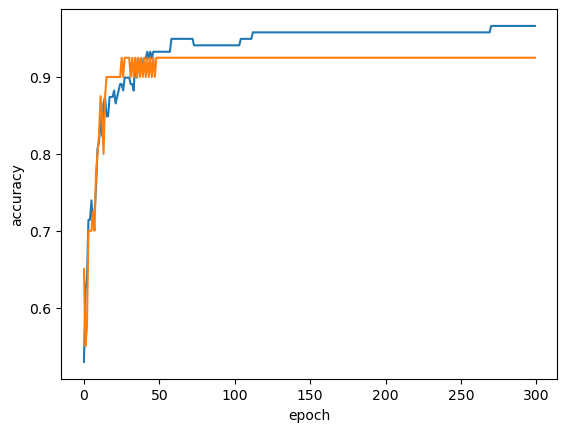

In [9]:
import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

⇒ 백 번째 에포크 이후에는 훈련 세트와 테스트 세트의 점수가 조금씩 벌어지고 있음

In [10]:
# SGDClassifier의 반복 횟수를 100에 맞추고 모델을 다시 훈련

sc = SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925


- SGDClassifier는 일정 에포크 동안 성능이 향상되지 않으면 더 훈련하지 않고 자동으로 멈춤
- tol 매개변수에서 향상될 최솟값을 지정하는데, 위 코드에서는 tol 매개변수를 None으로 지정하여 자동으로 멈추지 않고 max_iter=100 만큼 무조건 반복하도록 함

#### (+) 힌지 손실(Hinge Loss)과 서포트 벡터 머신(SVM)

1. 힌지 손실(Hinge Loss)
- 서포트 벡터 머신(SVM)에서 사용하는 손실 함수임
- 분류가 맞으면 손실 0, 틀리면 손실이 커짐
- 결정 경계에서 얼마나 멀리 떨어져 있는지를 기준으로 손실을 계산함

2. 서포트 벡터 머신(SVM)
- 클래스 사이의 경계(결정 경계)를 찾는 알고리즘임
- 두 클래스 사이의 **마진(margin)**을 최대화하는 결정 경계를 찾음
- 마진: 결정 경계와 가장 가까운 샘플 사이의 거리
- 경계에 가장 가까운 샘플들을 서포트 벡터라고 부름 (이 샘플들이 경계를 "지지"함)

In [11]:
sc = SGDClassifier(loss='hinge', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.9495798319327731
0.925


---

## 5. 확인 문제 해설

### 1. 표준화 같은 데이터 전처리를 수행하지 않아도 되는 방식으로 구현된 클래스는?
**정답: ② LinearRegression**

- KNeighborsClassifier: 거리 기반 알고리즘 → 표준화 **필요**
- LinearRegression: 정규방정식으로 해를 구함 → 표준화 **불필요**
- Ridge: 규제가 있어서 스케일에 영향 받음 → 표준화 **필요**
- SGDClassifier: 경사 하강법이라 스케일에 민감함 → 표준화 **필요**

### 2. 경사 하강법 알고리즘의 하나로 훈련 세트에서 몇 개의 샘플을 뽑아서 훈련하는 방식은?
**정답: ③ 미니배치 경사 하강법**

- 확률적 경사 하강법: 1개씩 뽑아서 훈련
- 배치 경사 하강법: 전체를 사용해서 훈련
- 미니배치 경사 하강법: **여러 개(몇 개)** 를 뽑아서 훈련
- 부분배치 경사 하강법: 존재하지 않는 용어

### 3. SGDClassifier 클래스에서 에포크 횟수를 지정하는 매개변수는?
**정답: ① max_iter**

- max_iter: 에포크 횟수 지정
- epochs: SGDClassifier에 없는 매개변수 (케라스 등에서 사용)
- shuffle: 에포크마다 훈련 세트를 섞을지 여부
- loss: 손실 함수 종류 지정

### 4. 경사 하강법에 대해 잘못 설명한 것은?
**정답: ④ SGDClassifier는 한 번에 훈련 세트를 모두 사용하는 배치 경사 하강법을 수행합니다**

- ① 손실 함수는 샘플 하나에 대한 손실을 정의하고 비용 함수는 모든 샘플에 대한 손실의 합으로 정의됩니다 → **맞음**
- ② 확률적 경사 하강법은 훈련 샘플을 하나씩 사용해서 손실 함수의 최솟값을 찾습니다 → **맞음**
- ③ 미니 배치 경사 하강법은 한 번에 여러 개의 샘플을 사용해 손실 함수를 최적화합니다 → **맞음**
- ④ SGDClassifier는 배치 경사 하강법을 수행합니다 → **틀림** (확률적 경사 하강법을 수행함)